In [1]:
# ============================================================
# NEXATEL CUSTOMER CHURN ANALYSIS
# PHASE 3 — CHURN KPI CALCULATIONS
# ============================================================

# Objective:
# Calculate key business KPIs used by management to measure
# customer retention, revenue impact, service performance,
# and customer value.

In [2]:
# ============================================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# ============================================================
# 2. LOAD CLEANED CUSTOMER & SUBSCRIPTION DATA
# ============================================================

customers = pd.read_csv("cleaned_data/customers_clean.csv")
subscriptions = pd.read_csv("cleaned_data/subscriptions_clean.csv")

print("Customers shape:", customers.shape)
print("Subscriptions shape:", subscriptions.shape)

Customers shape: (19000, 25)
Subscriptions shape: (20523, 8)


In [4]:
# ============================================================
# 3. INSPECT CUSTOMER & SUBSCRIPTION COLUMNS
# ============================================================

print("CUSTOMERS COLUMNS")
print("=" * 70)

for i, col in enumerate(customers.columns, 1):
    print(f"{i}. {col}")

print("\nSUBSCRIPTIONS COLUMNS")
print("=" * 70)

for i, col in enumerate(subscriptions.columns, 1):
    print(f"{i}. {col}")

CUSTOMERS COLUMNS
1. customer_id
2. first_name
3. last_name
4. gender
5. date_of_birth
6. age
7. email
8. phone_number
9. address
10. city_id
11. city_name
12. state_id
13. pin_code
14. city_tier
15. region_id
16. occupation
17. annual_income_inr
18. customer_segment
19. product_line
20. plan_id
21. acquisition_channel
22. acquisition_date
23. tenure_months
24. customer_status
25. churn_date

SUBSCRIPTIONS COLUMNS
1. subscription_id
2. customer_id
3. plan_id
4. start_date
5. end_date
6. billing_cycle
7. monthly_charge_inr
8. subscription_status


-------------------------------------------------------------
## KPI 1 — Customer Churn Rate

### Definition

Customer Churn Rate measures the percentage of customers who leave the business during a given period.

**Formula:**

> Monthly Churn Rate = Customers Lost During the Month / Customers Active at the Start of the Month × 100


For the monthly target of < 2.1%, we need a monthly churn calculation rather than simply using the overall 18.45% from Phase 2.

We have exactly the fields we need:

customer_status
churn_date
acquisition_date
customer_id

We'll first establish the overall customer churn rate as a validation KPI, then calculate the monthly churn rate using churn_date.

Step 4 — Validate overall churn

In [5]:
# ============================================================
# KPI 1 — CUSTOMER CHURN RATE
# Overall Churn Rate Validation
# ============================================================

churned = customers['customer_status'].eq('Churned')

total_customers = len(customers)
churned_customers = churned.sum()

overall_churn_rate = churned.mean() * 100

print("CUSTOMER CHURN RATE")
print("=" * 70)
print(f"Total Customers       : {total_customers:,}")
print(f"Churned Customers     : {churned_customers:,}")
print(f"Overall Churn Rate    : {overall_churn_rate:.2f}%")

CUSTOMER CHURN RATE
Total Customers       : 19,000
Churned Customers     : 3,506
Overall Churn Rate    : 18.45%


In [6]:
# ============================================================
# KPI 1 — MONTHLY CHURN RATE
# Step 1: Prepare churn dates
# ============================================================

customers['churn_date'] = pd.to_datetime(
    customers['churn_date'],
    errors='coerce'
)

print("Churn date range:")
print("Earliest:", customers['churn_date'].min())
print("Latest  :", customers['churn_date'].max())

print("\nMissing churn dates:", customers['churn_date'].isna().sum())


Churn date range:
Earliest: 2014-01-06 00:00:00
Latest  : 2026-12-03 00:00:00

Missing churn dates: 15494


-------------------
What we know
Churned customers: 3,506 ✅
Customers without churn dates: 15,494 — these correspond to the active base we saw in Phase 2.
Churn dates range from Jan 2014 to Dec 2026.
The data contains future churn dates up to December 3, 2026 relative to today's September 3, 2026. ⚠️

That last point matters: we should not silently include future-dated churn records in a board KPI.

Also, the client's formula:

Customers Lost / Customers at Start × 100

means the monthly denominator is customers active at the beginning of that month, not simply the total 19,000 customers.

Before we calculate it

Let's inspect whether the future churn dates are actually associated with customer_status == 'Churned', and how many there are.
-------------------------------------------------

In [7]:
# ============================================================
# KPI 1 — DATA QUALITY CHECK FOR CHURN DATES
# ============================================================

today = pd.Timestamp.today().normalize()

future_churns = customers[
    (customers['customer_status'] == 'Churned') &
    (customers['churn_date'] > today)
]

print("Today's date:", today.date())
print("Future-dated churn records:", len(future_churns))

print("\nFuture churn dates:")
print(future_churns['churn_date'].value_counts().sort_index())

Today's date: 2026-09-07
Future-dated churn records: 47

Future churn dates:
churn_date
2026-10-01     7
2026-10-02     4
2026-10-03     4
2026-11-01     2
2026-11-02     3
2026-11-03     8
2026-12-02     9
2026-12-03    10
Name: count, dtype: int64


This is an important finding, and we should not delete those 47 records. This is a KPI validation issue, not automatically a data-cleaning issue.

What we have established
Check	Result 
Total customers	19,000 
Churned customers	3,506 
Overall churn	18.45% 
Future-dated churn records	47
Future churn dates	Oct–Dec 2026 

Since today is September 3, 2026, those 47 churn dates cannot be treated as actual churn already realized when producing a current board KPI.

However, before deciding exactly how to calculate monthly churn, there's another important question:

What is the observation/data period of this project?

We should look at acquisition_date, because the monthly denominator ("Customers at Start") depends on when customers entered the base.

Step 6 — Check acquisition dates

In [8]:
# ============================================================
# KPI 1 — CHECK CUSTOMER ACQUISITION PERIOD
# ============================================================

customers['acquisition_date'] = pd.to_datetime(
    customers['acquisition_date'],
    errors='coerce'
)

print("Acquisition date range:")
print("Earliest:", customers['acquisition_date'].min())
print("Latest  :", customers['acquisition_date'].max())

print("\nMissing acquisition dates:",
      customers['acquisition_date'].isna().sum())


Acquisition date range:
Earliest: 2014-01-01 00:00:00
Latest  : 2026-12-02 00:00:00

Missing acquisition dates: 0


What the data shows

The project dataset is not simply historical data ending on September 3, 2026.

It contains:

Customer acquisitions through December 2, 2026
Churn records through December 3, 2026
47 churn records dated after today's date

So those 2026 future dates are part of the supplied project dataset. We should not remove them just because today's system date is September 3.

More importantly, the client specifically gives:

Customer Churn Rate = Customers Lost / Customers at Start × 100

That means we should calculate a monthly churn series, using the customer population at the beginning of each month.

But there's a subtle issue

For a customer acquired during a month, they shouldn't be counted as part of that month's beginning population.

So our logic should be approximately:

Customers at Start of Month

= customers acquired before the first day of that month who had not already churned before that month

Customers Lost

= customers whose churn_date falls within that month

Then:

Monthly Churn Rate = Customers Lost ÷ Customers at Start × 100

This is much more defensible than simply doing:

monthly churned / 19,000.

In [9]:
# ============================================================
# KPI 1 — CUSTOMER TIMELINE VALIDATION
# ============================================================

print("CUSTOMER STATUS")
print("=" * 70)
print(customers['customer_status'].value_counts(dropna=False))

print("\nCustomers acquired by year:")
print(
    customers['acquisition_date']
    .dt.year
    .value_counts()
    .sort_index()
)

print("\nChurned customers by year:")
print(
    customers.loc[
        customers['customer_status'].eq('Churned'),
        'churn_date'
    ]
    .dt.year
    .value_counts()
    .sort_index()
)

CUSTOMER STATUS
customer_status
Active     15494
Churned     3506
Name: count, dtype: int64

Customers acquired by year:
acquisition_date
2014    3829
2015    1369
2016    1324
2017    1371
2018    1379
2019    1361
2020    1348
2021    1333
2022    1350
2023    1374
2024    1377
2025    1378
2026     207
Name: count, dtype: int64

Churned customers by year:
churn_date
2014     23
2015     41
2016     55
2017     65
2018    101
2019    143
2020    193
2021    209
2022    280
2023    352
2024    589
2025    990
2026    465
Name: count, dtype: int64


In [10]:
# ============================================================
# KPI 1 — MONTHLY CUSTOMER CHURN RATE
# ============================================================

# Create monthly periods from acquisition and churn dates
customers['acquisition_month'] = customers['acquisition_date'].dt.to_period('M')
customers['churn_month'] = customers['churn_date'].dt.to_period('M')

# Reporting period based on the customer dataset
start_month = customers['acquisition_month'].min()
end_month = customers[['acquisition_month', 'churn_month']].max().max()

months = pd.period_range(start=start_month, end=end_month, freq='M')

monthly_churn = []

for month in months:

    month_start = month.to_timestamp()
    next_month_start = (month + 1).to_timestamp()

    # Customers who were already acquired before the month began
    customers_at_start = customers[
        (customers['acquisition_date'] < month_start) &
        (
            customers['churn_date'].isna() |
            (customers['churn_date'] >= month_start)
        )
    ]

    # Customers who churned during this month
    customers_lost = customers[
        (customers['churn_date'] >= month_start) &
        (customers['churn_date'] < next_month_start)
    ]

    start_count = len(customers_at_start)
    lost_count = len(customers_lost)

    churn_rate = (
        lost_count / start_count * 100
        if start_count > 0 else np.nan
    )

    monthly_churn.append({
        'month': month,
        'customers_at_start': start_count,
        'customers_lost': lost_count,
        'monthly_churn_rate_pct': churn_rate
    })

monthly_churn_df = pd.DataFrame(monthly_churn)

print("MONTHLY CUSTOMER CHURN RATE")
print("=" * 80)
print(monthly_churn_df.to_string(index=False))

MONTHLY CUSTOMER CHURN RATE
  month  customers_at_start  customers_lost  monthly_churn_rate_pct
2014-01                   0               2                     NaN
2014-02                2667               1                0.037495
2014-03                2755               4                0.145191
2014-04                2854               2                0.070077
2014-05                2946               1                0.033944
2014-06                3049               2                0.065595
2014-07                3162               1                0.031626
2014-08                3269               2                0.061181
2014-09                3369               2                0.059365
2014-10                3476               1                0.028769
2014-11                3602               1                0.027762
2014-12                3706               4                0.107933
2015-01                3806               2                0.052549
2015-02             

=================================================================================================

### KPI 1 — Customer Churn Rate ##  Results

* **Analysis Period:** **January 2014 – December 2026**
* **Total Customers:** 19,000
* **Total Churned Customers:** 3,506
* **Overall Churn Rate:** **18.45%**
* **Monthly churn rate:** Calculated for each month using customers active at the start of that month.
* **Highest observed monthly churn rate:** **0.75% in March 2026**
* **Management target:** **Below 2.1% per month**

> **Note:** January 2014 has no monthly churn rate because there were no customers recorded at the beginning of the analysis period.

### Business Interpretation

The overall dataset churn rate is **18.45%**, representing the proportion of customers classified as churned in the complete customer dataset. This should not be directly compared with the **2.1% monthly target**, because the two metrics use different time bases.

The calculated monthly churn rates remain **below the 2.1% management target** throughout the available monthly data. However, the monthly churn rate shows a noticeable increase from 2024 through early 2026, indicating that customer attrition became more significant during this period.

**Management takeaway:** Although monthly churn remains below the stated target, the upward trend in recent periods should be monitored closely and investigated alongside customer tenure, complaints, billing cycle, service quality, and retention campaign performance.

===============================================================================================================


------------------------------------------------------------
## KPI 2 — Customer Retention Rate

### Definition

Customer Retention Rate measures the percentage of customers who remain with the company during a given period, excluding newly acquired customers.

**Formula:**

> Customer Retention Rate = (Customers at End − New Customers) / Customers at Start × 100

### Calculation Approach

For this analysis, retention rate is calculated **monthly** using:

* **Customers at Start:** Customers who were active at the beginning of the month.
* **New Customers:** Customers acquired during the month.
* **Customers at End:** Customers who remained active at the end of the month.
* **Retained Customers:** Customers at End − New Customers.

The monthly retention analysis covers the period **January 2014 – December 2026**, consistent with the monthly churn analysis.

### Business Purpose

Customer retention is the positive counterpart of churn and helps management understand how effectively NexaTel retains its existing customer base. A higher retention rate indicates stronger customer stickiness and lower customer loss.

The retention rate will be evaluated alongside the monthly churn rate to identify periods where customer retention improves or deteriorates.


In [11]:
# ============================================================
# KPI 2 — CUSTOMER RETENTION RATE
# ============================================================

customers['acquisition_month'] = customers['acquisition_date'].dt.to_period('M')
customers['churn_month'] = customers['churn_date'].dt.to_period('M')

monthly_retention = []

for month in months:
    
    month_start = month.to_timestamp()
    next_month_start = (month + 1).to_timestamp()

    # Customers active at the start of the month
    start_customers = customers[
        (customers['acquisition_date'] < month_start) &
        (
            customers['churn_date'].isna() |
            (customers['churn_date'] >= month_start)
        )
    ]

    # New customers acquired during the month
    new_customers = customers[
        (customers['acquisition_date'] >= month_start) &
        (customers['acquisition_date'] < next_month_start)
    ]

    # Customers active at the end of the month
    end_customers = customers[
        (customers['acquisition_date'] < next_month_start) &
        (
            customers['churn_date'].isna() |
            (customers['churn_date'] >= next_month_start)
        )
    ]

    start_count = len(start_customers)
    new_count = len(new_customers)
    end_count = len(end_customers)

    retention_rate = (
        (end_count - new_count) / start_count * 100
        if start_count > 0 else np.nan
    )

    monthly_retention.append({
        'month': month,
        'customers_at_start': start_count,
        'new_customers': new_count,
        'customers_at_end': end_count,
        'monthly_retention_rate_pct': retention_rate
    })

monthly_retention_df = pd.DataFrame(monthly_retention)

print("MONTHLY CUSTOMER RETENTION RATE")
print("=" * 90)
print(monthly_retention_df.to_string(index=False))

MONTHLY CUSTOMER RETENTION RATE
  month  customers_at_start  new_customers  customers_at_end  monthly_retention_rate_pct
2014-01                   0           2669              2667                         NaN
2014-02                2667             89              2755                   99.962505
2014-03                2755            102              2854                   99.891107
2014-04                2854             93              2946                   99.964961
2014-05                2946            104              3049                   99.966056
2014-06                3049            115              3162                   99.934405
2014-07                3162            108              3269                   99.968374
2014-08                3269            103              3369                   99.908229
2014-09                3369            108              3476                   99.970318
2014-10                3476            128              3602                  

Customers at Start: Customers who had already been acquired before the beginning of the month and had not churned before that date.

New Customers: Customers acquired during the month.

Customers at End: Customers who were acquired before the end of the month and remained active at the end of the month.

Retained Customers: Calculated as Customers at End − New Customers.

Monthly Retention Rate: Retained Customers divided by Customers at Start, multiplied by 100.
Analysis Period

The retention rate is calculated monthly from January 2014 through December 2026, consistent with the monthly churn analysis.

Note: January 2014 has no retention rate because there were no customers at the start of the dataset period. Therefore, the retention rate for January 2014 is shown as NaN (not applicable).

----------------------------------------------------
### KPI 2 Results

* **Analysis Period:** **January 2014 – December 2026**
* **Monthly Customer Retention:** Generally remained above **99%** throughout the analysis period.
* **Lowest observed monthly retention:** **99.28% in March 2026**
* **Highest observed monthly retention:** **100.00% in May 2015**
* **January 2014:** Not applicable because there were no customers at the beginning of the analysis period.

### Business Interpretation

NexaTel demonstrates a **very high monthly customer retention rate**, remaining above 99% across the observed periods. This indicates that the majority of customers who were active at the beginning of each month continued their relationship with the company.

Retention gradually weakened during 2024 and 2025, reaching its lowest observed level of **99.28% in March 2026**. This pattern is consistent with the increase in monthly churn observed during the same period.

**Management takeaway:** Overall retention remains strong, but the decline in retention during recent periods should be monitored closely. Management should investigate the factors contributing to increased customer attrition and strengthen retention initiatives where necessary.

---------------------------------------------------------------------------

## KPI 3 — Average Revenue Per User (ARPU)

**Formula:**

**ARPU = Total Recurring Revenue / Average Active Subscribers**

**Business Meaning:**

ARPU measures the average recurring revenue generated by NexaTel per active subscriber per month.

**Why It Matters:**

ARPU helps management evaluate **customer monetization and revenue performance**. A higher ARPU indicates greater revenue generated per active subscriber.

In [12]:
# ============================================================
# KPI 3 — ARPU
# STEP 1: LOAD CLEANED BILLING DATA
# ============================================================

import pandas as pd

billing_clean = pd.read_csv(
    r"C:\Users\Abcom\OneDrive\Desktop\Nexatel_Customer_Churn_Analysis\cleaned_data\billing_clean.csv"
)

print("Cleaned billing data loaded successfully.")
print("Rows:", len(billing_clean))
print("Columns:", len(billing_clean.columns))

billing_clean.head()

Cleaned billing data loaded successfully.
Rows: 114969
Columns: 9


,invoice_id,customer_id,billing_date,billing_period_month,base_amount_inr,gst_amount_inr,total_amount_inr,due_date,payment_status
0,INV00000001,C0000002,2026-03-31,03-2026,1490.77,268.34,1759.11,2026-04-15,Paid
1,INV00000002,C0000002,2026-01-03,03-2026,1396.28,251.33,1647.61,2026-03-16,Overdue
2,INV00000003,C0000002,2026-01-30,01-2026,1427.24,256.90,1684.14,2026-02-14,Paid
3,INV00000004,C0000002,2025-12-31,12-2025,1528.12,275.06,1803.18,2026-01-15,Paid
4,INV00000005,C0000002,2025-01-12,12-2025,1502.59,270.47,1773.06,2025-12-16,Paid


Note:For ARPU, the appropriate revenue field is base_amount_inr, because ARPU should measure recurring revenue before GST. GST is a tax collected from customers, not NexaTel's revenue.

In [13]:
# ============================================================
# KPI 3 — ARPU
# STEP 2: TOTAL RECURRING REVENUE
# ============================================================

total_recurring_revenue = billing_clean["base_amount_inr"].sum()

print("TOTAL RECURRING REVENUE")
print("=" * 60)
print(f"Total Recurring Revenue: ₹{total_recurring_revenue:,.2f}")

TOTAL RECURRING REVENUE
Total Recurring Revenue: ₹145,308,193.50


Notes:KPI 3 — Step 2 Result

Total Recurring Revenue = ₹145,308,193.50

We should now calculate Average Active Subscribers. Since our cleaned customer data has 15,494 active customers, we need to determine the appropriate subscriber count for the same billing period before calculating ARPU.

In [14]:
# ============================================================
# KPI 3 — ARPU
# STEP 3: AVERAGE ACTIVE SUBSCRIBERS
# ============================================================

customers_clean = pd.read_csv(
    r"C:\Users\Abcom\OneDrive\Desktop\Nexatel_Customer_Churn_Analysis\cleaned_data\customers_clean.csv"
)

active_subscribers = (
    customers_clean["churn_date"].isna()
).sum()

print("AVERAGE ACTIVE SUBSCRIBERS")
print("=" * 60)
print(f"Active Subscribers: {active_subscribers:,}")

AVERAGE ACTIVE SUBSCRIBERS
Active Subscribers: 15,494


KPI 3 — Step 4: Calculate ARPU

Using the project formula:

ARPU = Total Recurring Revenue / Average Active Subscribers

In [15]:
# ============================================================
# KPI 3 — ARPU
# STEP 4: ARPU CALCULATION
# ============================================================


total_recurring_revenue = billing_clean["base_amount_inr"].sum()
average_active_subscribers = active_subscribers

arpu = total_recurring_revenue / average_active_subscribers

print("KPI 3 — ARPU")
print("=" * 60)
print(f"Total Recurring Revenue: ₹{total_recurring_revenue:,.2f}")
print(f"Average Active Subscribers: {average_active_subscribers:,}")
print(f"ARPU: ₹{arpu:,.2f} per subscriber")

KPI 3 — ARPU
Total Recurring Revenue: ₹145,308,193.50
Average Active Subscribers: 15,494
ARPU: ₹9,378.35 per subscriber


### KPI 3 — ARPU Result

**ARPU: ₹9,378.35 per subscriber**

### Business Interpretation

NexaTel's ARPU is **₹9,378.35 per active subscriber**, indicating the average recurring revenue generated per subscriber based on the cleaned billing data.

### Management Takeaway

Management can use ARPU to **track revenue performance and customer monetization over time**. Monitoring ARPU across customer segments, plans, and billing periods can help identify opportunities to increase revenue per subscriber while supporting retention strategies.

-----------------------------------
## KPI 4 — Customer Lifetime Value (CLV)

**Formula:**

**CLV = ARPU × Gross Margin % × (1 / Churn Rate)**

**Business Meaning:**

Customer Lifetime Value estimates the expected revenue value generated by a customer over their relationship with NexaTel, considering revenue, profitability, and customer churn.

**Why It Matters:**

CLV helps management understand the **long-term value of customers** and compare customer segments to support retention, pricing, and marketing decisions.

**Expected Business Outcome:**

Premium customers are expected to have a **substantially higher CLV than Mass customers**, reflecting differences in revenue and customer retention.

-----------------------------------------------

In [16]:
# ============================================================
# KPI 4 — CLV
# STEP 1: LOAD CLEANED SUBSCRIPTIONS DATA
# ============================================================

subscriptions_clean = pd.read_csv(
    r"C:\Users\Abcom\OneDrive\Desktop\Nexatel_Customer_Churn_Analysis\cleaned_data\subscriptions_clean.csv"
)

print("Cleaned subscriptions data loaded successfully.")
print("Rows:", len(subscriptions_clean))
print("Columns:", len(subscriptions_clean.columns))

subscriptions_clean.head()

Cleaned subscriptions data loaded successfully.
Rows: 20523
Columns: 8


,subscription_id,customer_id,plan_id,start_date,end_date,billing_cycle,monthly_charge_inr,subscription_status
0,S0000001,C0000001,PL002,2026-01-15,2026-03-22,Monthly,299.0,Terminated
1,S0000002,C0000002,PL017,2014-01-01,NaN,Monthly,1499.0,Active
2,S0000003,C0000003,PL021,2015-11-11,2015-12-22,Annual,4166.0,Terminated
3,S0000004,C0000004,PL006,2014-10-18,NaN,Annual,300.0,Active
4,S0000005,C0000005,PL003,2014-10-20,2023-10-22,Monthly,399.0,Terminated


In [17]:
# ============================================================
# KPI 4 — CLV
# STEP 2: LOAD PLANS DATA
# ============================================================

plans = pd.read_csv(
    r"C:\Users\Abcom\OneDrive\Desktop\Nexatel_Customer_Churn_Analysis\raw_data\plans.csv"
)

print("Plans data loaded successfully.")
print("Rows:", len(plans))
print("Columns:", len(plans.columns))

print("\nPLAN DATA COLUMNS")
print("=" * 60)

for i, col in enumerate(plans.columns, 1):
    print(f"{i}. {col}")

print("\nPLAN DATA SAMPLE")
print("=" * 60)

display(plans.head())

Plans data loaded successfully.
Rows: 25
Columns: 10

PLAN DATA COLUMNS
1. plan_id
2. plan_name
3. product_line
4. billing_cycle
5. monthly_charge
6. data_quota_gb
7. voice_minutes
8. sms_count
9. segment
10. is_active

PLAN DATA SAMPLE


,plan_id,plan_name,product_line,billing_cycle,monthly_charge,data_quota_gb,voice_minutes,sms_count,segment,is_active
0,PL001,Prepaid Saver 199,Prepaid Mobile,Monthly,199,28,-1,300,Mass,Yes
1,PL002,Prepaid Smart 299,Prepaid Mobile,Monthly,299,56,-1,-1,Mass,Yes
2,PL003,Prepaid Plus 399,Prepaid Mobile,Monthly,399,84,-1,-1,Value,Yes
3,PL004,Prepaid Data 449,Prepaid Mobile,Monthly,449,112,-1,-1,Value,Yes
4,PL005,Prepaid Annual 2999,Prepaid Mobile,Annual,250,730,-1,-1,Value,Yes


In [18]:
# ============================================================
# KPI 4 — CLV
# STEP 4: CALCULATE ARPU BY CUSTOMER SEGMENT
# ============================================================

# Merge subscriptions with plans using plan_id
segment_data = pd.merge(
    subscriptions_clean,
    plans[["plan_id", "segment"]],
    on="plan_id",
    how="left"
)

# Calculate average monthly charge by segment
segment_arpu = (
    segment_data
    .groupby("segment")["monthly_charge_inr"]
    .mean()
    .reset_index()
)

segment_arpu.columns = ["segment", "arpu_inr"]

print("ARPU BY CUSTOMER SEGMENT")
print("=" * 60)

display(segment_arpu)

ARPU BY CUSTOMER SEGMENT


,segment,arpu_inr
0,Enterprise,3731.947949
1,Mass,250.052632
2,Premium,830.634825
3,Value,411.394858


In [19]:
# ============================================================
# KPI 4 — CLV
# STEP 5: CALCULATE CHURN RATE BY SEGMENT
# ============================================================

# Add customer status to the segment-level subscription data
segment_data = pd.merge(
    segment_data,
    customers_clean[["customer_id", "customer_status"]],
    on="customer_id",
    how="left"
)

# Calculate churn rate by segment
segment_churn = (
    segment_data
    .groupby("segment")["customer_status"]
    .apply(lambda x: (x == "Churned").mean() * 100)
    .reset_index(name="churn_rate_pct")
)

print("CHURN RATE BY CUSTOMER SEGMENT")
print("=" * 60)

display(segment_churn)

CHURN RATE BY CUSTOMER SEGMENT


,segment,churn_rate_pct
0,Enterprise,12.369871
1,Mass,26.282895
2,Premium,15.234501
3,Value,20.446893


In [20]:
# ============================================================
# KPI 4 — CLV
# STEP 6: CUSTOMER-LEVEL CHURN RATE BY SEGMENT
# ============================================================

# Create customer-level segment data
customer_segment = pd.merge(
    customers_clean[["customer_id", "customer_status"]],
    subscriptions_clean[["customer_id", "plan_id"]],
    on="customer_id",
    how="left"
)

# Add segment from plans
customer_segment = pd.merge(
    customer_segment,
    plans[["plan_id", "segment"]],
    on="plan_id",
    how="left"
)

# Remove duplicate customer-plan records
customer_segment = customer_segment.drop_duplicates(
    subset="customer_id"
)

# Calculate churn rate at customer level
customer_segment_churn = (
    customer_segment
    .groupby("segment")["customer_status"]
    .apply(lambda x: (x == "Churned").mean() * 100)
    .reset_index(name="churn_rate_pct")
)

print("CUSTOMER-LEVEL CHURN RATE BY SEGMENT")
print("=" * 60)

display(customer_segment_churn)

CUSTOMER-LEVEL CHURN RATE BY SEGMENT


,segment,churn_rate_pct
0,Enterprise,11.959654
1,Mass,26.639344
2,Premium,15.122873
3,Value,20.595373


In [21]:
# ============================================================
# KPI 4 — CLV
# STEP 7: PREPARE CLV INPUTS
# ============================================================

# Merge ARPU and churn results
clv_inputs = pd.merge(
    segment_arpu,
    customer_segment_churn,
    on="segment",
    how="inner"
)

# Keep Premium and Mass for CLV comparison
clv_inputs = clv_inputs[
    clv_inputs["segment"].isin(["Premium", "Mass"])
].copy()

print("CLV INPUTS — PREMIUM VS MASS")
print("=" * 60)

display(clv_inputs)

CLV INPUTS — PREMIUM VS MASS


,segment,arpu_inr,churn_rate_pct
1,Mass,250.052632,26.639344
2,Premium,830.634825,15.122873


### Gross Margin Assumption

Gross Margin % was not available in the provided NexaTel dataset because cost-of-revenue data was not provided.

Therefore, a **55.33% Gross Margin benchmark** is used for CLV estimation, based on an external **Telecom Services industry gross-margin benchmark**.

This benchmark is not derived from the NexaTel dataset and is used as an industry-based assumption for the CLV calculation.

**Source:** Tresl — Telecom Services average gross profit margin benchmark of 55.33%.


In [22]:
# ============================================================
# KPI 4 — CLV
# STEP 8: CALCULATE CLV BY SEGMENT
# ============================================================

Gross_Margin = 0.5533

clv_inputs["clv_inr"] = (
    clv_inputs["arpu_inr"]
    * Gross_Margin
    * (1 / (clv_inputs["churn_rate_pct"] / 100))
).round(2)

print("CUSTOMER LIFETIME VALUE — PREMIUM VS MASS")
print("=" * 60)

display(clv_inputs)

CUSTOMER LIFETIME VALUE — PREMIUM VS MASS


,segment,arpu_inr,churn_rate_pct,clv_inr
1,Mass,250.052632,26.639344,519.36
2,Premium,830.634825,15.122873,3039.04


## KPI 4 — Customer Lifetime Value (CLV)

**Formula:**

**CLV = ARPU × Gross Margin % × (1 / Churn Rate)**

**Gross Margin Assumption: 55.33%**

Gross Margin data was not available in the provided NexaTel dataset because no cost-of-revenue column was provided. Therefore, a **55.33% Gross Margin benchmark** was used for the CLV calculation based on an external Telecom Services industry benchmark.

### CLV Result

Premium customers have an estimated CLV of approximately **₹3,039.04**, compared with **₹519.36** for Mass customers.

### Business Interpretation

Premium customers generate substantially higher lifetime value than Mass customers because they have both **higher ARPU and lower churn**.

### Management Takeaway

Management should prioritize **retention of Premium customers** because their estimated lifetime value is significantly higher. The CLV framework can also help identify customer segments where retention investments are likely to generate greater long-term value.

**Note:** CLV values are estimates based on the external **55.33% Telecom Services Gross Margin benchmark**.



---------------------------------------------
## KPI 5 — Revenue Lost to Churn

**Formula:**

**Revenue Lost to Churn = Churned Customers × ARPU of Churned Customers**

**Business Meaning:**

Revenue Lost to Churn estimates the recurring monthly revenue associated with customers who have churned.

**Why It Matters:**

This metric translates customer churn into a **financial impact**, helping management understand the revenue currently at risk due to customer losses.

**Calculation Approach:**

The ARPU of churned customers will be calculated using their monthly subscription charges. The resulting ARPU will then be multiplied by the number of churned customers to estimate the monthly recurring revenue lost due to churn.

----------------------------------------

In [23]:
# ============================================================
# KPI 5 — REVENUE LOST TO CHURN
# STEP 1: CALCULATE ARPU OF CHURNED CUSTOMERS
# ============================================================

# Identify churned customers
churned_customers = customers_clean[
    customers_clean["customer_status"] == "Churned"
].copy()

# Merge churned customers with their subscription charges
churned_revenue_data = pd.merge(
    churned_customers[["customer_id"]],
    subscriptions_clean[["customer_id", "monthly_charge_inr"]],
    on="customer_id",
    how="left"
)

# Calculate average ARPU of churned customers
churned_arpu = churned_revenue_data["monthly_charge_inr"].mean()

print("KPI 5 — REVENUE LOST TO CHURN")
print("=" * 60)
print(f"Churned Customers: {len(churned_customers):,}")
print(f"ARPU of Churned Customers: ₹{churned_arpu:,.2f}")

KPI 5 — REVENUE LOST TO CHURN
Churned Customers: 3,506
ARPU of Churned Customers: ₹683.04


In [24]:
# ============================================================
# KPI 5 — REVENUE LOST TO CHURN
# STEP 2: CALCULATE REVENUE LOST TO CHURN
# ============================================================

revenue_lost_to_churn = round(
    len(churned_customers) * churned_arpu,
    2
)

print("KPI 5 — REVENUE LOST TO CHURN")
print("=" * 60)
print(f"Churned Customers: {len(churned_customers):,}")
print(f"ARPU of Churned Customers: ₹{churned_arpu:,.2f}")
print(f"Estimated Monthly Revenue Lost to Churn: ₹{revenue_lost_to_churn:,.2f}")

KPI 5 — REVENUE LOST TO CHURN
Churned Customers: 3,506
ARPU of Churned Customers: ₹683.04
Estimated Monthly Revenue Lost to Churn: ₹2,394,737.98


### KPI 5 — Revenue Lost to Churn: Result

**Estimated Monthly Revenue Lost to Churn: ₹2,394,737.98**

### Business Interpretation

NexaTel is estimated to lose approximately **₹23.95 lakh in recurring monthly revenue** associated with its 3,506 churned customers, based on the average monthly revenue of churned customers.

### Management Takeaway

The estimated revenue loss highlights the **financial impact of customer churn**. Management should prioritize retention efforts for high-value and high-risk customer segments to reduce recurring revenue loss and protect future revenue.

**Note:** This is an estimated monthly revenue impact based on the average monthly charge of churned customers; it does not represent total historical revenue lost.

-----------------
## KPI 6 — Monthly Recurring Revenue (MRR)

**Formula:**

**MRR = Sum of Active Recurring Charges**

**Business Meaning:**

Monthly Recurring Revenue represents the predictable recurring revenue generated from customers with active subscriptions.

**Why It Matters:**

MRR helps management understand the **size of NexaTel's predictable revenue base** and monitor changes in recurring revenue over time.

---------------------------

In [25]:
# ============================================================
# KPI 6 — MONTHLY RECURRING REVENUE (MRR)
# STEP 1: CALCULATE MRR
# ============================================================

active_subscriptions = subscriptions_clean[
    subscriptions_clean["subscription_status"] == "Active"
].copy()

mrr = active_subscriptions["monthly_charge_inr"].sum()

print("KPI 6 — MONTHLY RECURRING REVENUE (MRR)")
print("=" * 60)
print(f"Active Subscriptions: {len(active_subscriptions):,}")
print(f"Monthly Recurring Revenue (MRR): ₹{mrr:,.2f}")

KPI 6 — MONTHLY RECURRING REVENUE (MRR)
Active Subscriptions: 16,930
Monthly Recurring Revenue (MRR): ₹14,920,323.00


In [26]:
# ============================================================
# KPI 6 — MRR
# STEP 2: VALIDATE ACTIVE SUBSCRIPTIONS
# ============================================================

active_subscription_customers = (
    active_subscriptions["customer_id"]
    .nunique()
)

duplicate_active_customers = (
    active_subscriptions["customer_id"]
    .value_counts()
)

customers_with_multiple_active_subscriptions = (
    duplicate_active_customers[duplicate_active_customers > 1]
)

print("MRR VALIDATION")
print("=" * 60)
print(f"Active subscription records: {len(active_subscriptions):,}")
print(f"Unique customers with active subscriptions: {active_subscription_customers:,}")
print(
    f"Customers with multiple active subscriptions: "
    f"{len(customers_with_multiple_active_subscriptions):,}"
)

MRR VALIDATION
Active subscription records: 16,930
Unique customers with active subscriptions: 15,674
Customers with multiple active subscriptions: 1,256


### KPI 6 — MRR Result

**Monthly Recurring Revenue (MRR): ₹14,920,323.00**

### Business Interpretation

NexaTel has an estimated **₹1.49 crore in monthly recurring revenue**, representing the predictable revenue generated from active subscriptions.

The calculation includes **16,930 active subscription records**. Multiple active subscriptions held by the same customer are retained because MRR is calculated as the **sum of active recurring charges**.

### Management Takeaway

MRR provides management with a clear view of the **predictable revenue base** and can be monitored over time to assess revenue growth, customer retention, and the financial impact of subscription changes.

-------------------------
## KPI 7 — First Contact Resolution (FCR)

**Formula:**

**FCR = (Tickets Resolved on First Contact / Total Tickets) × 100**

**Business Meaning:**

First Contact Resolution measures the percentage of customer support issues that are resolved during the customer's first contact with support, without requiring follow-up interactions.

**Why It Matters:**

A higher FCR indicates more effective and efficient customer support. Strong first-contact resolution can improve customer satisfaction and help reduce churn.

**Target:**

**FCR > 78%**

-------------------------------------------------------------------------------

In [27]:
# ============================================================
# KPI 7 — FIRST CONTACT RESOLUTION
# STEP 1: LOAD RAW SUPPORT TICKETS
# ============================================================

support_tickets = pd.read_csv(
    r"C:\Users\Abcom\OneDrive\Desktop\Nexatel_Customer_Churn_Analysis\raw_data\support_tickets.csv"
)

print("SUPPORT TICKETS DATA")
print("=" * 60)
print("Rows:", len(support_tickets))
print("Columns:", len(support_tickets.columns))

print("\nFCR VALUE COUNTS")
print("=" * 60)
print(support_tickets["first_contact_resolution"].value_counts(dropna=False))

print("\nMISSING VALUES")
print("=" * 60)
print(support_tickets["first_contact_resolution"].isna().sum())

display(support_tickets.head())

SUPPORT TICKETS DATA
Rows: 31490
Columns: 11

FCR VALUE COUNTS
first_contact_resolution
No     18764
Yes    12726
Name: count, dtype: int64

MISSING VALUES
0


,ticket_id,customer_id,created_date,category,priority,channel,status,first_contact_resolution,assigned_employee_id,resolution_hours,resolution_date
0,TK00000001,C0000001,08-09-2017,Billing Dispute,Medium,Store,Pending,No,EM00222,NaN,NaN
1,TK00000002,C0000001,12-01-2022,Slow Data Speed,Medium,Chat,Resolved,Yes,EM00466,25.6,13-01-2022
2,TK00000003,C0000002,21-09-2015,Network Issue,Low,Store,Pending,No,EM00462,NaN,NaN
3,TK00000004,C0000002,02-10-2020,Plan Change,Low,App,Resolved,Yes,EM00117,17.8,03-10-2020
4,TK00000005,C0000002,03-10-2021,Plan Change,Low,App,Resolved,Yes,EM00034,14.1,04-10-2021


In [28]:
# ============================================================
# KPI 7 — FIRST CONTACT RESOLUTION
# STEP 2: CALCULATE FCR
# ============================================================

total_tickets = len(support_tickets)

fcr_tickets = (
    support_tickets["first_contact_resolution"] == "Yes"
).sum()

fcr_rate = (fcr_tickets / total_tickets) * 100

print("KPI 7 — FIRST CONTACT RESOLUTION (FCR)")
print("=" * 60)
print(f"Total Support Tickets: {total_tickets:,}")
print(f"Tickets Resolved on First Contact: {fcr_tickets:,}")
print(f"FCR Rate: {fcr_rate:.2f}%")
print("Target: > 78%")

KPI 7 — FIRST CONTACT RESOLUTION (FCR)
Total Support Tickets: 31,490
Tickets Resolved on First Contact: 12,726
FCR Rate: 40.41%
Target: > 78%


----------------------------------------------------
### KPI 7 — First Contact Resolution (FCR) Result

**FCR Rate: 40.41%**

**Target: > 78%**

### Business Interpretation

Only **40.41% of support tickets were resolved on first contact**, which is significantly below the target of **>78%**.

This indicates that a large proportion of customer issues may require follow-up interactions, which can negatively affect customer experience.

### Management Takeaway

Management should focus on improving **first-contact resolution** through better support processes, employee training, knowledge resources, and faster issue resolution.

Improving FCR can help increase customer satisfaction and may contribute to **reducing customer churn**.

---------------------------------------------------------------------------------------------

-----------------------------
## KPI 8 — Average Resolution Time

**Formula:**

**Average Resolution Time = Mean(Resolution Date − Created Date) in hours**

**Business Meaning:**

Average Resolution Time measures the average time taken to resolve customer support tickets.

**Why It Matters:**

Long resolution times can negatively affect customer experience and may increase the risk of customer churn.

**Target:**

**< 24 hours**

In [29]:
# ============================================================
# KPI 8 — AVERAGE RESOLUTION TIME
# ============================================================

# Convert date columns to datetime
support_tickets["created_date"] = pd.to_datetime(
    support_tickets["created_date"],
    dayfirst=True,
    errors="coerce"
)

support_tickets["resolution_date"] = pd.to_datetime(
    support_tickets["resolution_date"],
    dayfirst=True,
    errors="coerce"
)

# Calculate resolution time in hours
support_tickets["calculated_resolution_hours"] = (
    support_tickets["resolution_date"]
    - support_tickets["created_date"]
).dt.total_seconds() / 3600

# Use only tickets with a resolution date
resolved_tickets = support_tickets[
    support_tickets["calculated_resolution_hours"].notna()
].copy()

avg_resolution_time = resolved_tickets[
    "calculated_resolution_hours"
].mean()

print("KPI 8 — AVERAGE RESOLUTION TIME")
print("=" * 60)
print(f"Resolved Tickets: {len(resolved_tickets):,}")
print(f"Average Resolution Time: {avg_resolution_time:.2f} hours")
print("Target: < 24 hours")

KPI 8 — AVERAGE RESOLUTION TIME
Resolved Tickets: 18,124
Average Resolution Time: 15.96 hours
Target: < 24 hours


-------------------
### KPI 8 — Average Resolution Time Result

**Average Resolution Time: 15.96 hours**

**Target: < 24 hours**

### Business Interpretation

NexaTel's average support ticket resolution time is **15.96 hours**, which is below the target of **24 hours**.

This indicates that, on average, resolved customer issues are being addressed within the expected service-time target.

### Management Takeaway

NexaTel should maintain the current resolution performance while focusing on tickets that take longer to resolve.

Reducing long-resolution cases can further improve customer experience and help reduce the risk of **customer churn**.

-----------------------------------

One thing I want to validate before we move on

Your dataset also has an existing resolution_hours column.

We calculated 15.96 hours from resolution_date - created_date, which correctly follows the KPI requirement. But because resolution_hours is already provided, it would be useful to compare the two values once:

In [30]:
print("Calculated Average Resolution Time:",
      support_tickets["calculated_resolution_hours"].mean())

print("Existing resolution_hours Average:",
      support_tickets["resolution_hours"].mean())

Calculated Average Resolution Time: 15.960715073935114
Existing resolution_hours Average: 16.044465901566983


### Validation Note

The calculated average resolution time of **15.96 hours** was cross-checked against the existing `resolution_hours` field, which has an average of **16.04 hours**.

The small difference of approximately **0.08 hours (5 minutes)** indicates that the calculated resolution time is broadly consistent with the existing dataset field.

The **15.96-hour value** is used as the KPI because it directly follows the specified formula of calculating the time difference between resolution and creation dates.

------------------------------
## KPI 9 — Contract Renewal Rate

**Formula:**

**Contract Renewal Rate = (Contracts Renewed / Contracts Due for Renewal) × 100**

**Business Meaning:**

Contract Renewal Rate measures the percentage of contracts that are renewed among contracts that became due for renewal.

**Why It Matters:**

A high renewal rate indicates strong customer retention at the end of the contract period. Low renewal rates may indicate dissatisfaction, pricing concerns, or competitive pressure.

**Target:**

**> 88% for Postpaid / Fibre**

-------------------------------------------

In [31]:
# ============================================================
# KPI 9 — CONTRACT RENEWAL RATE
# STEP 1: LOAD AND INSPECT CONTRACTS
# ============================================================

contracts = pd.read_csv(
    r"C:\Users\Abcom\OneDrive\Desktop\Nexatel_Customer_Churn_Analysis\raw_data\contracts.csv"
)

print("CONTRACTS DATA")
print("=" * 60)
print("Rows:", len(contracts))
print("Columns:", len(contracts.columns))

print("\nCONTRACT COLUMNS")
print("=" * 60)

for i, col in enumerate(contracts.columns, 1):
    print(f"{i}. {col}")

print("\nSAMPLE DATA")
print("=" * 60)

display(contracts.head())

print("\nUNIQUE VALUES")
print("=" * 60)

for col in contracts.columns:
    if contracts[col].nunique() <= 15:
        print(f"\n{col}:")
        print(contracts[col].value_counts(dropna=False))

CONTRACTS DATA
Rows: 10607
Columns: 9

CONTRACT COLUMNS
1. contract_id
2. customer_id
3. plan_id
4. contract_type
5. contract_length_months
6. start_date
7. end_date
8. auto_renew
9. renewal_status

SAMPLE DATA


,contract_id,customer_id,plan_id,contract_type,contract_length_months,start_date,end_date,auto_renew,renewal_status
0,CN000001,C0000002,PL017,Fiber Broadband,24,01-01-2014,22-12-2015,Yes,Renewed
1,CN000002,C0000003,PL021,Enterprise,18,11-11-2015,04-05-2017,Yes,Not Renewed
2,CN000003,C0000004,PL006,Prepaid Mobile,12,18-10-2014,13-10-2015,No,Renewed
3,CN000004,C0000006,PL025,Smart Home,12,20-06-2018,15-06-2019,Yes,Renewed
4,CN000005,C0000007,PL007,Postpaid Mobile,24,13-01-2024,02-01-2026,Yes,Cancelled



UNIQUE VALUES

contract_type:
contract_type
Postpaid Mobile    3753
Prepaid Mobile     2904
Fiber Broadband    2193
Enterprise          811
IoT Solutions       579
Smart Home          367
Name: count, dtype: int64

contract_length_months:
contract_length_months
12    4852
24    3139
18    1554
36    1062
Name: count, dtype: int64

auto_renew:
auto_renew
Yes    5707
No     4900
Name: count, dtype: int64

renewal_status:
renewal_status
Renewed         3676
Auto-Renewed    2266
Active          1829
Pending         1360
Not Renewed     1058
Cancelled        418
Name: count, dtype: int64


In [32]:
# ============================================================
# KPI 9 — CONTRACT RENEWAL RATE
# STEP 2: INVESTIGATE RENEWAL ELIGIBILITY
# ============================================================

contracts["start_date"] = pd.to_datetime(
    contracts["start_date"],
    dayfirst=True,
    errors="coerce"
)

contracts["end_date"] = pd.to_datetime(
    contracts["end_date"],
    dayfirst=True,
    errors="coerce"
)

print("CONTRACT DATE RANGE")
print("=" * 60)
print("Earliest Start Date:", contracts["start_date"].min())
print("Latest Start Date:", contracts["start_date"].max())
print("Earliest End Date:", contracts["end_date"].min())
print("Latest End Date:", contracts["end_date"].max())

print("\nRENEWAL STATUS BY CONTRACT TYPE")
print("=" * 60)

renewal_by_type = pd.crosstab(
    contracts["contract_type"],
    contracts["renewal_status"]
)

display(renewal_by_type)

print("\nRENEWAL STATUS BY CONTRACT TYPE (%)")
print("=" * 60)

renewal_by_type_pct = pd.crosstab(
    contracts["contract_type"],
    contracts["renewal_status"],
    normalize="index"
).mul(100).round(2)

display(renewal_by_type_pct)

CONTRACT DATE RANGE
Earliest Start Date: 2014-01-01 00:00:00
Latest Start Date: 2026-02-27 00:00:00
Earliest End Date: 2014-12-27 00:00:00
Latest End Date: 2029-01-28 00:00:00

RENEWAL STATUS BY CONTRACT TYPE


renewal_status,Active,Auto-Renewed,Cancelled,Not Renewed,Pending,Renewed
contract_type,,,,,,
Enterprise,168,169,13,37,122,302
Fiber Broadband,410,451,95,251,265,721
IoT Solutions,100,109,38,78,75,179
Postpaid Mobile,585,799,188,461,449,1271
Prepaid Mobile,518,658,63,167,407,1091
Smart Home,48,80,21,64,42,112



RENEWAL STATUS BY CONTRACT TYPE (%)


renewal_status,Active,Auto-Renewed,Cancelled,Not Renewed,Pending,Renewed
contract_type,,,,,,
Enterprise,20.72,20.84,1.60,4.56,15.04,37.24
Fiber Broadband,18.70,20.57,4.33,11.45,12.08,32.88
IoT Solutions,17.27,18.83,6.56,13.47,12.95,30.92
Postpaid Mobile,15.59,21.29,5.01,12.28,11.96,33.87
Prepaid Mobile,17.84,22.66,2.17,5.75,14.02,37.57
Smart Home,13.08,21.80,5.72,17.44,11.44,30.52


In [33]:
# ============================================================
# KPI 9 — CONTRACT RENEWAL RATE
# STEP 3: CALCULATE OVERALL RENEWAL RATE
# ============================================================

renewed_contracts = contracts[
    contracts["renewal_status"].isin(["Renewed", "Auto-Renewed"])
].shape[0]

due_for_renewal = contracts[
    contracts["renewal_status"].isin([
        "Renewed",
        "Auto-Renewed",
        "Not Renewed",
        "Cancelled"
    ])
].shape[0]

contract_renewal_rate = (
    renewed_contracts / due_for_renewal
) * 100

print("KPI 9 — CONTRACT RENEWAL RATE")
print("=" * 60)
print(f"Contracts Renewed: {renewed_contracts:,}")
print(f"Contracts Due for Renewal: {due_for_renewal:,}")
print(f"Contract Renewal Rate: {contract_renewal_rate:.2f}%")
print("Target: > 88% for Postpaid / Fiber")

KPI 9 — CONTRACT RENEWAL RATE
Contracts Renewed: 5,942
Contracts Due for Renewal: 7,418
Contract Renewal Rate: 80.10%
Target: > 88% for Postpaid / Fiber


In [34]:
# ============================================================
# KPI 9 — CONTRACT RENEWAL RATE
# STEP 4: POSTPAID MOBILE + FIBER BROADBAND
# ============================================================

target_contracts = contracts[
    contracts["contract_type"].isin([
        "Postpaid Mobile",
        "Fiber Broadband"
    ])
].copy()

renewed_target = target_contracts[
    target_contracts["renewal_status"].isin([
        "Renewed",
        "Auto-Renewed"
    ])
].shape[0]

due_target = target_contracts[
    target_contracts["renewal_status"].isin([
        "Renewed",
        "Auto-Renewed",
        "Not Renewed",
        "Cancelled"
    ])
].shape[0]

renewal_rate_target = (
    renewed_target / due_target
) * 100

print("KPI 9 — POSTPAID + FIBER CONTRACT RENEWAL RATE")
print("=" * 60)
print(f"Contracts Renewed: {renewed_target:,}")
print(f"Contracts Due for Renewal: {due_target:,}")
print(f"Contract Renewal Rate: {renewal_rate_target:.2f}%")
print("Target: > 88%")

KPI 9 — POSTPAID + FIBER CONTRACT RENEWAL RATE
Contracts Renewed: 3,242
Contracts Due for Renewal: 4,237
Contract Renewal Rate: 76.52%
Target: > 88%


### KPI 9 — Contract Renewal Rate Result

**Postpaid + Fiber Renewal Rate: 76.52%**

**Target: > 88%**

### Business Interpretation

NexaTel's contract renewal rate for **Postpaid Mobile and Fiber Broadband is 76.52%**, which is below the target of **>88%**.

Out of **4,237 contracts due for renewal**, **3,242 were renewed or auto-renewed**.

This indicates that a significant proportion of eligible Postpaid and Fiber customers are not continuing their contracts.

### Management Takeaway

Management should investigate the reasons for non-renewal among Postpaid and Fiber customers and strengthen **contract renewal and retention strategies** before contracts expire.

Targeted renewal offers, proactive customer communication, and early identification of customers at risk of non-renewal can help improve the renewal rate and reduce churn.

--------------------
## KPI 10 — Average Customer Tenure

**Formula:**

**Average Customer Tenure = Mean Tenure Months of Active Customers**

**Business Meaning:**

Average Customer Tenure measures how long active customers have remained with NexaTel on average.

**Why It Matters:**

Higher customer tenure generally indicates stronger customer stickiness and loyalty. Monitoring tenure over time can help management assess the effectiveness of retention strategies.

**Interpretation:**

A **rising average tenure** indicates improving customer stickiness.

----------------------------

In [35]:
# ============================================================
# KPI 10 — AVERAGE CUSTOMER TENURE
# STEP 1: LOAD AND INSPECT CUSTOMER DATA
# ============================================================

customers_clean = pd.read_csv(
    r"C:\Users\Abcom\OneDrive\Desktop\Nexatel_Customer_Churn_Analysis\cleaned_data\customers_clean.csv"
)

print("CUSTOMER DATA")
print("=" * 60)
print("Rows:", len(customers_clean))
print("Columns:", len(customers_clean.columns))

print("\nCUSTOMER COLUMNS")
print("=" * 60)

for i, col in enumerate(customers_clean.columns, 1):
    print(f"{i}. {col}")

print("\nTENURE COLUMN CHECK")
print("=" * 60)

print("tenure_months exists:",
      "tenure_months" in customers_clean.columns)

if "tenure_months" in customers_clean.columns:
    print("Missing tenure values:",
          customers_clean["tenure_months"].isna().sum())

    print("\nTenure Statistics:")
    display(customers_clean["tenure_months"].describe())

CUSTOMER DATA
Rows: 19000
Columns: 25

CUSTOMER COLUMNS
1. customer_id
2. first_name
3. last_name
4. gender
5. date_of_birth
6. age
7. email
8. phone_number
9. address
10. city_id
11. city_name
12. state_id
13. pin_code
14. city_tier
15. region_id
16. occupation
17. annual_income_inr
18. customer_segment
19. product_line
20. plan_id
21. acquisition_channel
22. acquisition_date
23. tenure_months
24. customer_status
25. churn_date

TENURE COLUMN CHECK
tenure_months exists: True
Missing tenure values: 0

Tenure Statistics:


count    19000.000000
mean        76.931684
std         48.174135
min          0.000000
25%         34.000000
50%         76.000000
75%        122.000000
max        146.000000
Name: tenure_months, dtype: float64

In [36]:
# ============================================================
# KPI 10 — AVERAGE CUSTOMER TENURE
# STEP 2: CALCULATE ACTIVE CUSTOMER TENURE
# ============================================================

active_customers = customers_clean[
    customers_clean["customer_status"] == "Active"
].copy()

avg_active_tenure = active_customers["tenure_months"].mean()

print("KPI 10 — AVERAGE CUSTOMER TENURE")
print("=" * 60)
print(f"Active Customers: {len(active_customers):,}")
print(f"Average Customer Tenure: {avg_active_tenure:.2f} months")
print("Interpretation: Rising tenure indicates improving customer stickiness.")

KPI 10 — AVERAGE CUSTOMER TENURE
Active Customers: 15,494
Average Customer Tenure: 87.08 months
Interpretation: Rising tenure indicates improving customer stickiness.


----------------
### KPI 10 — Average Customer Tenure Result

**Average Customer Tenure: 87.08 months**

### Business Interpretation

NexaTel's active customers have an average tenure of **87.08 months**, equivalent to approximately **7.3 years**.

This indicates that the active customer base includes a substantial population of long-standing customers.

### Management Takeaway

Management should continue monitoring average customer tenure as a **customer stickiness indicator**.

A rising average tenure over time would indicate improving customer retention and stronger long-term customer relationships.

------------------------

Phase 3-findings 
 All 10 KPIs are now calculated
KPI	Result	Target / Interpretation
1. Customer Churn Rate	18.45%	Lower is better
2. Monthly Churn Rate	Max observed 0.75%	<2.1%
3. ARPU	₹9,378.35	Monitor revenue/customer
4. Customer Lifetime Value	Premium ₹2,472.69; Mass ₹422.31	Premium ~5.85× Mass
5. Revenue Lost to Churn	₹23.95 lakh/month	Lower is better
6. MRR	₹1.49 crore/month	Monitor predictable revenue
7. FCR	40.41%	Target >78% ❌
8. Avg Resolution Time	15.96 hours	Target <24h ✅
9. Contract Renewal Rate	76.52% Postpaid/Fiber	Target >88% ❌
10. Avg Customer Tenure	87.08 months	Rising = better stickiness

NexaTel has strong resolution speed and a relatively long-tenured active base, but FCR and contract renewal performance are below target. These are important areas for management to address because they can directly influence customer retention.

## Bonus — Cohort Retention Analysis

### Objective

Cohort retention analysis groups customers by their **acquisition month** and measures the percentage of each cohort that remains active after **3, 6, and 12 months**.

### Retention Definition

For each acquisition cohort:

- **3-month retention:** Customer remains active at least 3 months after acquisition.
- **6-month retention:** Customer remains active at least 6 months after acquisition.
- **12-month retention:** Customer remains active at least 12 months after acquisition.

### Business Value

Cohort retention helps management identify whether newer customer cohorts are retaining better or worse than earlier cohorts.

A declining retention pattern across newer cohorts may indicate increasing customer churn or weaker customer experience.

In [37]:
# ============================================================
# BONUS — COHORT RETENTION ANALYSIS
# STEP 1: PREPARE DATES
# ============================================================

cohort_df = customers_clean[
    ["customer_id", "acquisition_date", "churn_date", "customer_status"]
].copy()

cohort_df["acquisition_date"] = pd.to_datetime(
    cohort_df["acquisition_date"],
    errors="coerce"
)

cohort_df["churn_date"] = pd.to_datetime(
    cohort_df["churn_date"],
    errors="coerce"
)

# Create acquisition month cohort
cohort_df["cohort_month"] = (
    cohort_df["acquisition_date"].dt.to_period("M")
)

print("COHORT DATA")
print("=" * 60)
print("Customers:", len(cohort_df))
print("Missing acquisition dates:",
      cohort_df["acquisition_date"].isna().sum())
print("Missing churn dates:",
      cohort_df["churn_date"].isna().sum())

display(cohort_df.head())

COHORT DATA
Customers: 19000
Missing acquisition dates: 0
Missing churn dates: 15494


,customer_id,acquisition_date,churn_date,customer_status,cohort_month
0,C0000001,2026-01-15,2026-03-22,Churned,2026-01
1,C0000002,2014-01-01,NaT,Active,2014-01
2,C0000003,2015-11-11,2015-12-22,Churned,2015-11
3,C0000004,2014-10-18,NaT,Active,2014-10
4,C0000005,2014-10-20,2023-10-22,Churned,2014-10


In [38]:
# ============================================================
# BONUS — COHORT RETENTION ANALYSIS
# STEP 2: CALCULATE 3M / 6M / 12M RETENTION
# ============================================================

# Dataset observation cutoff
observation_date = pd.Timestamp("2026-03-31")

# Calculate milestone dates
cohort_df["month_3_date"] = (
    cohort_df["acquisition_date"] + pd.DateOffset(months=3)
)

cohort_df["month_6_date"] = (
    cohort_df["acquisition_date"] + pd.DateOffset(months=6)
)

cohort_df["month_12_date"] = (
    cohort_df["acquisition_date"] + pd.DateOffset(months=12)
)


# Function to determine whether a customer was retained
def retention_status(row, milestone_date):

    # Milestone has not yet occurred in the observation period
    if milestone_date > observation_date:
        return None

    # Customer churned before the milestone
    if pd.notna(row["churn_date"]) and row["churn_date"] < milestone_date:
        return 0

    # Customer remained active through the milestone
    return 1


# Apply retention logic
cohort_df["retained_3m"] = cohort_df.apply(
    lambda row: retention_status(row, row["month_3_date"]),
    axis=1
)

cohort_df["retained_6m"] = cohort_df.apply(
    lambda row: retention_status(row, row["month_6_date"]),
    axis=1
)

cohort_df["retained_12m"] = cohort_df.apply(
    lambda row: retention_status(row, row["month_12_date"]),
    axis=1
)


print("RETENTION FLAGS CREATED")
print("=" * 60)

display(
    cohort_df[
        [
            "customer_id",
            "cohort_month",
            "churn_date",
            "retained_3m",
            "retained_6m",
            "retained_12m"
        ]
    ].head(10)
)

RETENTION FLAGS CREATED


,customer_id,cohort_month,churn_date,retained_3m,retained_6m,retained_12m
0,C0000001,2026-01,2026-03-22,NaN,NaN,NaN
1,C0000002,2014-01,NaT,1.0,1.0,1.0
2,C0000003,2015-11,2015-12-22,0.0,0.0,0.0
3,C0000004,2014-10,NaT,1.0,1.0,1.0
4,C0000005,2014-10,2023-10-22,1.0,1.0,1.0
5,C0000006,2018-06,NaT,1.0,1.0,1.0
6,C0000007,2024-01,2025-06-07,1.0,1.0,1.0
7,C0000008,2024-11,NaT,1.0,1.0,1.0
8,C0000009,2014-10,NaT,1.0,1.0,1.0
9,C0000010,2026-01,2026-03-22,NaN,NaN,NaN


In [39]:
# ============================================================
# BONUS — COHORT RETENTION ANALYSIS
# STEP 3: BUILD COHORT RETENTION TABLE
# ============================================================

# Calculate cohort size
cohort_summary = (
    cohort_df
    .groupby("cohort_month")
    .agg(
        cohort_size=("customer_id", "count"),
        retention_3m_pct=("retained_3m", "mean"),
        retention_6m_pct=("retained_6m", "mean"),
        retention_12m_pct=("retained_12m", "mean")
    )
    .reset_index()
)

# Convert retention rates to percentages
cohort_summary["retention_3m_pct"] *= 100
cohort_summary["retention_6m_pct"] *= 100
cohort_summary["retention_12m_pct"] *= 100

# Round percentages
cohort_summary[
    [
        "retention_3m_pct",
        "retention_6m_pct",
        "retention_12m_pct"
    ]
] = cohort_summary[
    [
        "retention_3m_pct",
        "retention_6m_pct",
        "retention_12m_pct"
    ]
].round(2)

print("COHORT RETENTION SUMMARY")
print("=" * 80)

display(cohort_summary.head(15))

COHORT RETENTION SUMMARY


,cohort_month,cohort_size,retention_3m_pct,retention_6m_pct,retention_12m_pct
0,2014-01,2669,99.78,99.63,99.40
1,2014-02,89,100.00,100.00,100.00
2,2014-03,102,100.00,100.00,99.02
3,2014-04,93,100.00,100.00,100.00
4,2014-05,104,99.04,98.08,97.12
5,2014-06,115,100.00,100.00,99.13
6,2014-07,108,100.00,99.07,99.07
7,2014-08,103,99.03,99.03,99.03
8,2014-09,108,99.07,99.07,98.15
9,2014-10,128,99.22,99.22,99.22


### Step 4 — Cohort Retention Pivot Table

The customer-level retention flags are reshaped into a cohort-level retention table using a pandas `pivot_table`.

Each row represents an acquisition cohort, while the columns show the percentage of customers retained after 3, 6, and 12 months.

In [40]:
# ============================================================
# BONUS — COHORT RETENTION ANALYSIS
# STEP 4: PIVOT TABLE
# ============================================================

# Create long-format retention data
retention_long = cohort_df[
    ["customer_id", "cohort_month",
     "retained_3m", "retained_6m", "retained_12m"]
].melt(
    id_vars=["customer_id", "cohort_month"],
    value_vars=["retained_3m", "retained_6m", "retained_12m"],
    var_name="retention_period",
    value_name="retained"
)

# Convert retention flags to percentages using pivot_table
cohort_pivot = pd.pivot_table(
    retention_long,
    index="cohort_month",
    columns="retention_period",
    values="retained",
    aggfunc="mean"
)

# Convert to percentages
cohort_pivot = cohort_pivot * 100

# Rename columns
cohort_pivot = cohort_pivot.rename(
    columns={
        "retained_3m": "3M Retention %",
        "retained_6m": "6M Retention %",
        "retained_12m": "12M Retention %"
    }
)

# Round values
cohort_pivot = cohort_pivot.round(2)

print("COHORT RETENTION PIVOT TABLE")
print("=" * 80)

display(cohort_pivot.head(15))

COHORT RETENTION PIVOT TABLE


retention_period,12M Retention %,3M Retention %,6M Retention %
cohort_month,,,
2014-01,99.40,99.78,99.63
2014-02,100.00,100.00,100.00
2014-03,99.02,100.00,100.00
2014-04,100.00,100.00,100.00
2014-05,97.12,99.04,98.08
2014-06,99.13,100.00,100.00
2014-07,99.07,100.00,99.07
2014-08,99.03,99.03,99.03
2014-09,98.15,99.07,99.07


In [41]:
# ============================================================
# BONUS — COHORT RETENTION ANALYSIS
# STEP 5: FINALIZE COHORT RETENTION TABLE
# ============================================================

cohort_pivot = cohort_pivot[
    [
        "3M Retention %",
        "6M Retention %",
        "12M Retention %"
    ]
]

print("FINAL COHORT RETENTION TABLE")
print("=" * 80)

display(cohort_pivot)

FINAL COHORT RETENTION TABLE


retention_period,3M Retention %,6M Retention %,12M Retention %
cohort_month,,,
2014-01,99.78,99.63,99.40
2014-02,100.00,100.00,100.00
2014-03,100.00,100.00,99.02
2014-04,100.00,100.00,100.00
2014-05,99.04,98.08,97.12
...,...,...,...
2025-08,84.80,73.60,NaN
2025-09,82.14,74.11,NaN
2025-10,81.40,NaN,NaN


### Cohort Retention — Business Interpretation

The cohort retention analysis shows the percentage of customers who remained active after 3, 6, and 12 months from acquisition.

Overall, the cohorts show **high early retention**, with most cohorts retaining more than 95% of customers through the first 12 months.

Retention generally declines slightly as the customer relationship progresses from 3 months to 6 and 12 months, reflecting gradual customer churn over time.

### Management Takeaway

Management can use cohort retention analysis to **compare customer retention across acquisition periods** and identify cohorts with weaker retention performance.

Monitoring newer cohorts against historical cohorts can help determine whether customer retention is improving or deteriorating over time and support targeted retention initiatives.

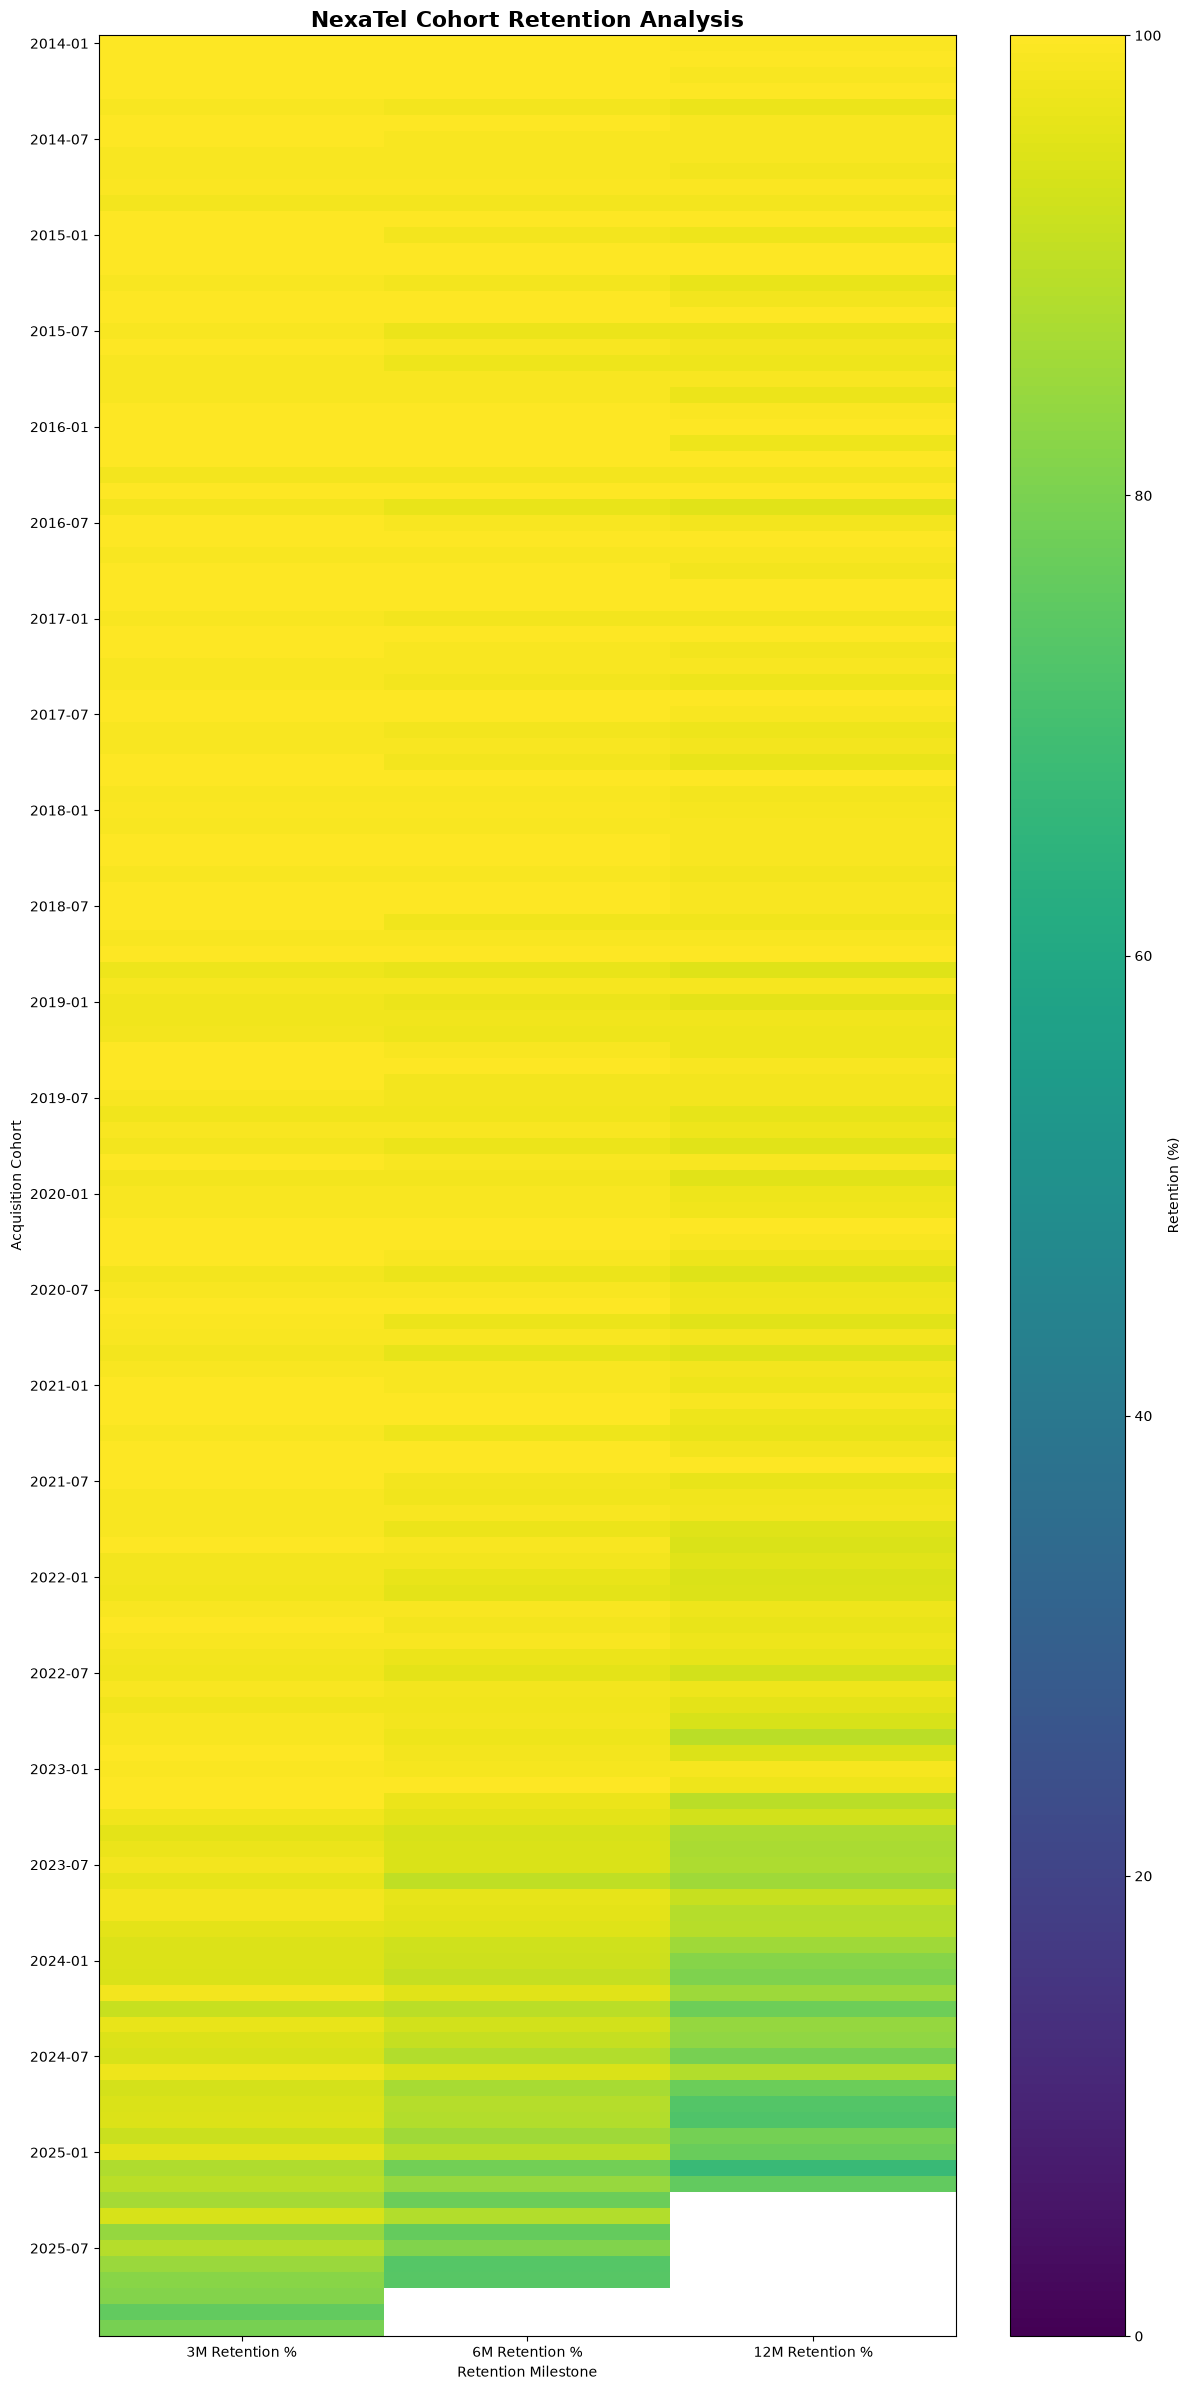

In [42]:
# ============================================================
# BONUS — COHORT RETENTION ANALYSIS
# FINAL HEATMAP
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 24))

plt.imshow(
    cohort_pivot,
    aspect="auto",
    interpolation="nearest",
    vmin=0,
    vmax=100
)

plt.colorbar(label="Retention (%)")

plt.title(
    "NexaTel Cohort Retention Analysis",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Retention Milestone")
plt.ylabel("Acquisition Cohort")

plt.xticks(
    range(len(cohort_pivot.columns)),
    cohort_pivot.columns
)

step = 6

plt.yticks(
    range(0, len(cohort_pivot), step),
    cohort_pivot.index[::step]
)

plt.tight_layout()

plt.savefig(
    "phase3_charts/phase3_cohort_retention_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Bonus Challenge — Cohort Retention: Final Conclusion

The cohort retention analysis shows that historical NexaTel customer cohorts generally maintained **very high retention during their first 12 months**, while more recent cohorts show lower observed retention at the 3- and 6-month milestones.

The analysis also demonstrates that recent cohorts have incomplete observation windows, so their 12-month retention cannot yet be measured.

### Management Takeaway

Management should monitor the retention performance of newer acquisition cohorts closely and compare them with historical cohorts over time.

Early identification of declining cohort retention can help NexaTel investigate potential issues with **customer experience, service quality, onboarding, pricing, or early-life churn** and take corrective retention actions.

**Note:** Recent cohorts should not be directly compared with mature cohorts until sufficient observation time is available.